Займемся Семантической Сегментации для выделения объектов на фотографии

**План семинара:**
* Данные
  * Загрузка данных Lyft-Udacity
  * Описание данных и введение в задачу
  * Подготовка датасета

* Метрика IoU (intersection over union)
* Лоссы задачи сегментации
  * BCE loss
  * DICE
* Модель SegNet
  * Простой способ
  * Реализация через классы
  * Upsampling варианты

* Train + Validation
* Test

Что нам нужно?
1. Датасет картинок вида: картинка -> маска
2. Определять, что сегментация верная? Метрика: IoU
3. Loss: CrossEntropy (для каждого пикселя предсказываем к какому он относится)
4. Определить, какую модель используем, возьмём SegNet (прототип)
5. Train, Test, Validation

In [3]:
!pip install wldhx.yadisk-direct

In [4]:
!curl -L $(yadisk-direct https://disk.yandex.com/d/jJrOLbYlBYVESQ) -o lyft_segmentation.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:--  0:00:01 --:--:--     0
100 2620M  100 2620M    0     0  19.7M      0  0:02:12  0:02:12 --:--:-- 18.6M


In [5]:
!unzip lyft_segmentation.zip

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: lyft_segmentation/segmentation_masks/F65-45.png  
  inflating: __MACOSX/lyft_segmentation/segmentation_masks/._F65-45.png  
  inflating: lyft_segmentation/segmentation_masks/F65-7.png  
  inflating: __MACOSX/lyft_segmentation/segmentation_masks/._F65-7.png  
  inflating: lyft_segmentation/segmentation_masks/02_01_024.png  
  inflating: __MACOSX/lyft_segmentation/segmentation_masks/._02_01_024.png  
  inflating: lyft_segmentation/segmentation_masks/02_00_237.png  
  inflating: __MACOSX/lyft_segmentation/segmentation_masks/._02_00_237.png  
  inflating: lyft_segmentation/segmentation_masks/F65-51.png  
  inflating: __MACOSX/lyft_segmentation/segmentation_masks/._F65-51.png  
  inflating: lyft_segmentation/segmentation_masks/F6-5.png  
  inflating: __MACOSX/lyft_segmentation/segmentation_masks/._F6-5.png  
  inflating: lyft_segmentation/segmentation_masks/02_01_030.png  
  inflating: __MACOSX/lyft_segmentatio

Датасет состоит из 2 папок: images (X) и segmentation_masks (y)

In [6]:
import numpy as np
import pandas as pd
from PIL import Image
import os
import matplotlib.pyplot as plt
import cv2

In [7]:
image_files = sorted(os.listdir("/content/lyft_segmentation/images"))
segmentation_files = sorted(os.listdir("/content/lyft_segmentation/segmentation_masks"))

In [8]:
len(image_files)

5000

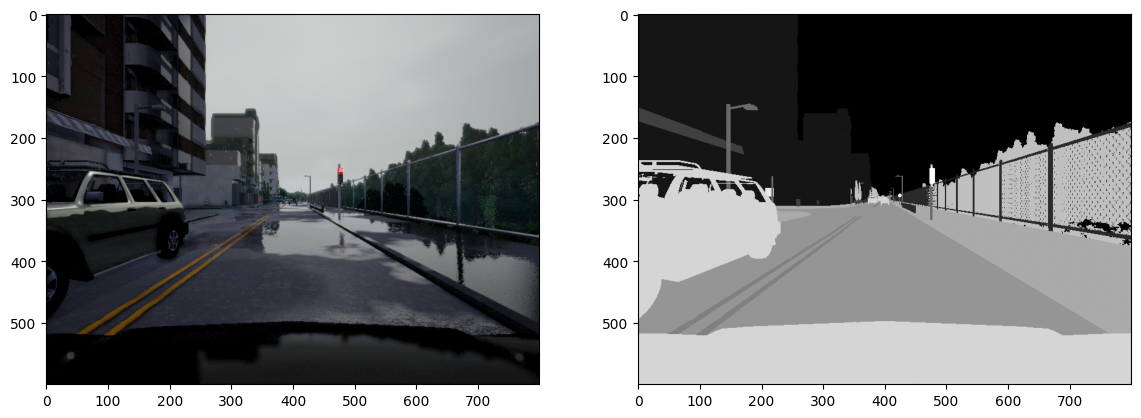

In [9]:
img = plt.imread(f"./lyft_segmentation/images/{image_files[0]}")
img_seg = plt.imread(f"./lyft_segmentation/segmentation_masks/{image_files[0]}")

fig = plt.figure(figsize=(14,10))

ax1 = plt.subplot(1,2,1)
plt.imshow(img)

ax2 = plt.subplot(1,2,2)
plt.imshow(img_seg[...,0], cmap='gray')

plt.show()

In [10]:
np.unique(img_seg * 255) # получается всего 13 классов

array([ 0.,  1.,  2.,  3.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.],
      dtype=float32)

In [11]:
labels = {
    0: 'Unlabeled',
    1: 'Building',
    2: 'Fence',
    3: 'Other',
    4: 'Pedestrian',
    5: 'Pole',
    6: 'Roadline',
    7: 'Road',
    8: 'Sidewalk',
    9: 'Vegetation',
    10: 'Car',
    11: 'Wall',
    12: 'Traffic sign'
}

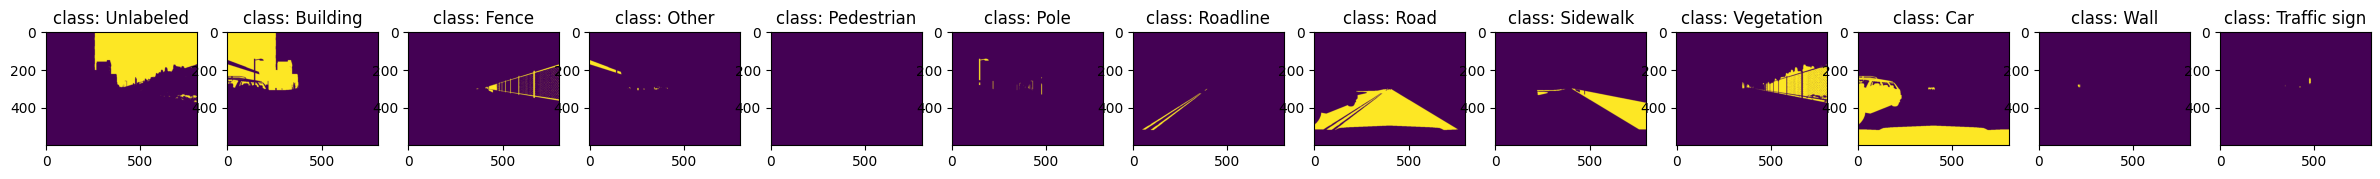

In [18]:
_, axes = plt.subplots(1, 13, figsize=(30,5))

for i in range(13): # 13 классов
  mask = plt.imread(f"/content/lyft_segmentation/segmentation_masks/{image_files[0]}") * 255
  mask = np.where(mask == i, 255, 0)
  mask = mask[:,:,0]

  axes[i].imshow(mask)
  axes[i].set_title(f"class: {labels[i]}")

### Создадим датасет

Нужны пути до RGB картинок в каждой папке

In [39]:
images = []
segmentation_masks = []

for img_name in os.listdir('/content/lyft_segmentation/images/'):
  images.append(f'./lyft_segmentation/images/{img_name}')

for img_name in os.listdir('/content/lyft_segmentation/segmentation_masks/'):
  segmentation_masks.append(f'./lyft_segmentation/segmentation_masks/{img_name}')

In [40]:
images[:5]

['./lyft_segmentation/images/02_00_243.png',
 './lyft_segmentation/images/07_00_127.png',
 './lyft_segmentation/images/F64-86.png',
 './lyft_segmentation/images/03_01_079.png',
 './lyft_segmentation/images/F10-10.png']

Теперь остановимся на 4 классах вместо 13
Создадим Датасет через класс, ведь он должен иметь методы __len__ и __getitem__

In [22]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torch
from torch import nn
from torch.nn import functional as F
from torchvision import transforms
import torchvision
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


Создаем класс для кастомного датасета. Давайте упростим задачу: будем сегментировать картинки только на четыре класса из представленных тринадцати:
- unlabeled;
- building;
- road;
- car.

In [41]:
class SelfDrivingDataset(Dataset):
  def __init__(self, images, segmentation_masks):
    self.images = images
    self.segmentation_masks = segmentation_masks

    self.image_transforms = torchvision.transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
    ])

    self.masks_transforms = torchvision.transforms.Compose([
        transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.NEAREST),
        transforms.ToTensor()
    ])

  def __getitem__(self, index):
    img = Image.open(self.images[index])
    mask = Image.open(self.segmentation_masks[index])

    img = self.image_transforms(img)
    mask = self.masks_transforms(mask) * 255

    masks = []

    for i in [0, 1, 7, 10]: #проходимся по классам
      cls_mask = torch.where(mask == i, 1, 0)
      masks.append(cls_mask[0, :, :].numpy())

    masks = torch.as_tensor(masks, dtype=torch.uint8)
    masks = torch.argmax(masks, axis=0)

    return (img, masks)

  def __len__(self):
    return len(self.images)

In [42]:
labels_used = ['Unlabeled', 'Building', 'Road', 'Car']

In [43]:
dataset = SelfDrivingDataset(images, segmentation_masks)

In [44]:
img, mask = dataset[3]

/tmp/ipython-input-419286072.py:30: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  masks = torch.as_tensor(masks, dtype=torch.uint8)


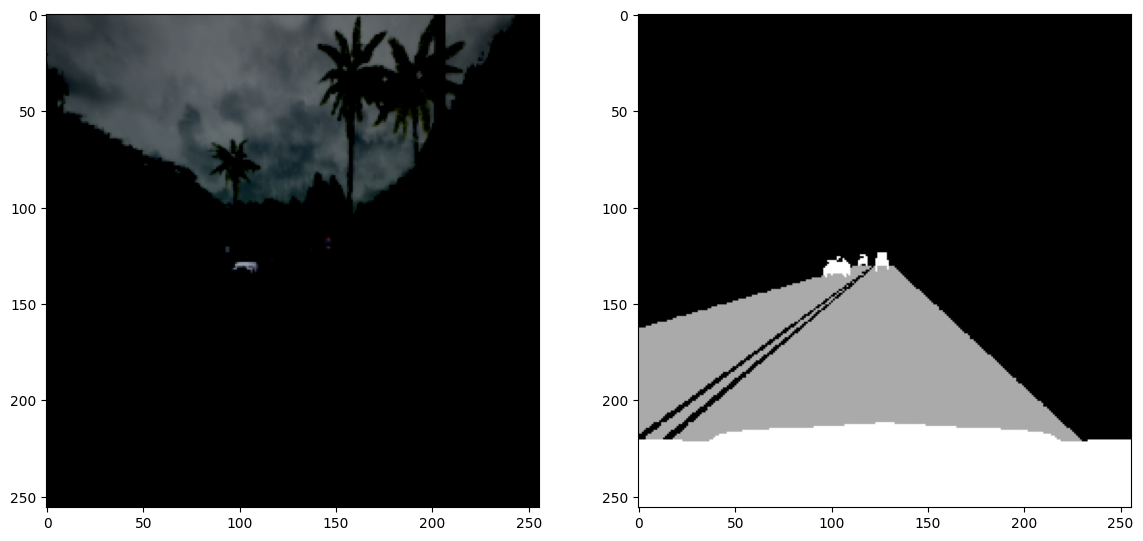

In [50]:
fig = plt.figure(figsize=(14,7))

ax1 = plt.subplot(1,2,1)
plt.imshow(img.permute(1,2,0))

ax2 = plt.subplot(1,2,2)
plt.imshow(mask, cmap='gray')
plt.show()

In [51]:
mask.unique()

tensor([0, 2, 3])

### Разделение на train и val

In [55]:
train_size = int(len(dataset) * 0.8)
val_size = len(dataset) - train_size

In [57]:
train_data, val_data = torch.utils.data.random_split(dataset, [train_size, val_size])

In [82]:
train_dataloader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
valid_dataloader = torch.utils.data.DataLoader(val_data, batch_size=64, shuffle=False)

## Metric IoU

Берётся пересечение у правильной и предсказанной картинки и делится на все предсказания вместе

In [60]:
!pip install torchmetrics

In [61]:
device = 'cuda'

In [63]:
from torchmetrics import JaccardIndex
import torch
import matplotlib.pyplot as plt
import numpy as np

jaccard = JaccardIndex(threshold=0.5, task='binary', average='none').to(device)

In [64]:
def iou_score(logits: torch.Tensor, labels: torch.Tensor, threshold: float = 0.5):
    # Lets compute metrics for some threshold
    # first convert mask values to probabilities, then
    # apply thresholding

    prob_mask = logits.sigmoid()
    pred_mask = (prob_mask > threshold).float()

    tp = torch.sum(pred_mask*labels)
    fp = torch.sum(pred_mask) - tp
    fn = torch.sum(labels) - tp

    eps = 1e-8 # to avoid 0/0
    iou = (tp + eps) / (tp + fp + fn + eps)

    return iou

In [65]:
!gdown --folder 1EX0RW1TRQVkLmR1h6miCQqyhYPFyg28M

Retrieving folder contents
Processing file 1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC labels.pt
Processing file 1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I logits.pt
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC
To: /content/for_asserts/labels.pt
100% 1.18k/1.18k [00:00<00:00, 5.58MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I
To: /content/for_asserts/logits.pt
100% 1.18k/1.18k [00:00<00:00, 6.77MB/s]
Download completed


In [66]:
path_to_dummy_samples = '/content/for_asserts'
dummpy_sample = {'logits': torch.load(f'{path_to_dummy_samples}/logits.pt'),
                 'labels': torch.load(f'{path_to_dummy_samples}/labels.pt')}
dummpy_sample['labels'] = dummpy_sample['labels'].to(device)
dummpy_sample['logits'] = dummpy_sample['logits'].to(device)

In [67]:
print(dummpy_sample['logits'])
print(dummpy_sample['logits'].sigmoid())
print(dummpy_sample['labels'])

tensor([[[[-1.9818, -3.0264, -3.4634, -3.3669],
          [-3.3132, -3.2690,  0.0526, -3.0650],
          [-3.1722,  0.2558,  0.2902, -3.2031],
          [-3.0457, -3.0761, -3.1206, -3.1873]]]], device='cuda:0')
tensor([[[[0.1211, 0.0462, 0.0304, 0.0333],
          [0.0351, 0.0367, 0.5131, 0.0446],
          [0.0402, 0.5636, 0.5720, 0.0390],
          [0.0454, 0.0441, 0.0423, 0.0396]]]], device='cuda:0')
tensor([[[[0., 0., 0., 0.],
          [0., 1., 1., 0.],
          [0., 1., 0., 0.],
          [0., 0., 0., 0.]]]], device='cuda:0')


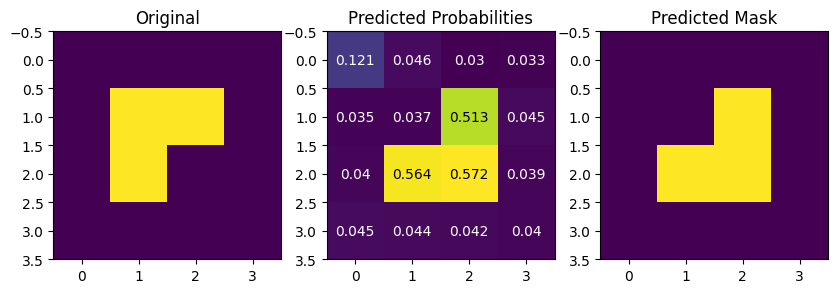

In [68]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize= (10,3*10))

ax1.imshow(dummpy_sample['labels'].squeeze(1)[0].cpu())
ax1.set_title("Original")

ax2.imshow(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu())
for (j,i),label in np.ndenumerate(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu()):
    if label < 0.5:
        color = 'white'
    else:
        color = 'black'
    ax2.text(i,j,round(label,3), color=color, ha='center',va='center')

ax2.set_title("Predicted Probabilities")

ax3.imshow((dummpy_sample['logits'].sigmoid() > 0.5).squeeze(1)[0].cpu())
ax3.set_title("Predicted Mask")
plt.show()

In [69]:
iou_ours = iou_score(dummpy_sample['logits'], dummpy_sample['labels'], threshold = 0.5)
iou_torch = jaccard(dummpy_sample['logits'], dummpy_sample['labels'])

In [70]:
assert iou_torch == iou_ours

## SegNet

In [71]:
loss = nn.CrossEntropyLoss()

In [73]:
import torchvision.models as models
model_ft = models.vgg16(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 131MB/s]


In [74]:
model_ft

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [75]:
class SegNet_Tiny(nn.Module):
    def __init__(self):
        super().__init__()

        # encoder (downsampling)
        self.enc_conv0 = nn.Conv2d(3, 8, kernel_size=3, padding=1)
        self.pool0 = nn.MaxPool2d((2, 2))  # 256 -> 128
        self.enc_bn0 = nn.BatchNorm2d(num_features=8)
        self.enc_conv1 = nn.Conv2d(8, 8, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d((2, 2)) # 128 -> 64
        self.enc_bn1 = nn.BatchNorm2d(num_features=8)
        self.enc_conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d((2, 2)) # 64 -> 32
        self.enc_bn2 = nn.BatchNorm2d(num_features=16)

        # bottleneck
        self.bottleneck_conv = nn.Conv2d(16, 16, kernel_size=1)

        # decoder (upsampling)
        self.upsample0 = nn.Upsample(scale_factor=2) # 32 -> 64
        self.dec_bn0 = nn.BatchNorm2d(num_features=32)
        # слой ConvTranspose2d c такими параметрами не меняет размер
        # карт активаций.
        self.dec_conv0 = nn.ConvTranspose2d(32, 8, 3, padding=1)
        self.upsample1 = nn.Upsample(scale_factor=2)  # 64 -> 128
        self.dec_bn1 = nn.BatchNorm2d(num_features=16)
        self.dec_conv1 = nn.ConvTranspose2d(16, 8, 3, padding=1)
        self.upsample2 = nn.Upsample(scale_factor=2)  # 128 -> 256
        self.dec_bn2 = nn.BatchNorm2d(num_features=16)
        self.dec_conv2 = nn.ConvTranspose2d(16, 4, 3, padding=1)

    def forward(self, x):
        # encoder
        e0 = self.enc_bn0(self.pool0(F.relu(self.enc_conv0(x))))
        e1 = self.enc_bn1(self.pool1(F.relu(self.enc_conv1(e0))))
        e2 = self.enc_bn2(self.pool2(F.relu(self.enc_conv2(e1))))

        # bottleneck
        b = self.bottleneck_conv(e2)

        # decoder
        d0 = self.dec_conv0(self.dec_bn0(F.relu(self.upsample0(torch.cat([b, e2], 1)))))
        d1 = self.dec_conv1(self.dec_bn1(F.relu(self.upsample1(torch.cat([d0, e1], 1)))))
        d2 = self.dec_conv2(self.dec_bn2(F.relu(self.upsample2(torch.cat([d1, e0], 1)))))

        return d2

## Train

In [76]:
import torch
from torchmetrics import JaccardIndex

from tqdm.notebook import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

In [78]:
def train_single_epoch(model, optimizer, criterion, train_dataloader, device):
    model.train()

    avg_loss = 0
    for X_batch, Y_batch in tqdm(train_dataloader):
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        Y_pred = model(X_batch)
        loss = criterion(Y_pred, Y_batch) # forward-pass

        loss.backward()  # backward-pass
        optimizer.step()  # update weights
        optimizer.zero_grad() # set parameter gradients to zero

        # calculate loss to show the user
        avg_loss += loss

    avg_loss = avg_loss/len(train_dataloader)

    return model, avg_loss

def validate_single_epoch(model, criterion, valid_dataloader, device, plot=False):

    iou_score = JaccardIndex(threshold=0.5, task="multiclass", num_classes=4, average='none').to(device)
    model.eval()

    avg_loss = 0
    avg_iou = 0
    with torch.no_grad():
      for X_batch, Y_batch in tqdm(valid_dataloader):
          X_batch = X_batch.to(device)
          Y_batch = Y_batch.to(device)

          Y_pred = model(X_batch)
          iou = iou_score(Y_pred, Y_batch)
          loss = criterion(Y_pred, Y_batch)
          avg_loss += loss
          avg_iou += iou

    avg_loss = avg_loss/len(valid_dataloader)
    avg_iou = avg_iou/len(valid_dataloader)

    if plot:
        clear_output(wait=True)
        our_labels = {
            0: 'Unlabeled',
            1: 'Building',
            2: 'Road',
            3: 'Car',
        }

        fig, axes = plt.subplots(1, 6, figsize=(6*4, 6*4))

        orig_img = X_batch[0].permute(1,2,0).cpu().detach().numpy()
        orig_mask = Y_batch[0].cpu().detach().numpy()

        axes[0].imshow(orig_img);
        axes[0].set_title("Original Image")

        diagram = axes[1].imshow(Y_batch[0].cpu().detach().numpy(), interpolation='none')
        values = np.unique(Y_batch[0].cpu().detach().numpy())
        colors = [ diagram.cmap(diagram.norm(value)) for value in values]
        patches = [ mpatches.Patch(color=colors[i], label=f"{i} - {our_labels[i]}" ) for i in range(len(values)) ]
        axes[1].legend(handles=patches, bbox_to_anchor=(1.00, 1), loc=1, borderaxespad=0. )
        axes[1].set_title("Original Mask")

        for i in range(Y_pred.shape[1]):
            axes[2+i].imshow(Y_pred[0].cpu().detach().numpy()[i]>0.5)
            axes[2+i].set_title(f"{our_labels[i]}, iou = {'%.3f' % avg_iou[i]}")

        plt.show()

    return model, avg_loss, avg_iou

def train(model, optimizer, criterion, epochs, train_dataloader, valid_dataloader, device, ckpt_path, plot_loss = False):

    total_train_loss = []
    total_val_loss = []
    total_val_iou = []

    best_val_loss = float('inf')
    best_val_iou = 0

    for epoch in tqdm(range(epochs)):

        model, train_loss = train_single_epoch(model, optimizer, criterion, train_dataloader, device)
        model, val_loss, val_iou = validate_single_epoch(model, criterion, valid_dataloader, device, plot=True)
        print(f'Epoch {epoch}: train loss = {train_loss}')
        print(f'Epoch {epoch}: val loss = {val_loss}')
        print(f'Epoch {epoch}: val iou = {val_iou}')

        total_train_loss.append(train_loss.cpu().detach().numpy())
        total_val_loss.append(val_loss.cpu().detach().numpy())
        total_val_iou.append(val_iou.cpu().detach().numpy())

        if plot_loss:
            fig, (ax1, ax2) = plt.subplots(1, 2)

            ax1.plot(list(range(len(total_train_loss))), total_train_loss, label = 'train loss')
            ax1.plot(list(range(len(total_val_loss))), total_val_loss, label = 'val loss')
            for i in range(len(val_iou)):
              ax2.plot(list(range(len(total_val_iou))), total_val_iou, label = f'val iou: {i}')
            ax1.set_title("Loss")
            ax2.set_title("IoU")
            ax1.legend()
            plt.show()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), f'{ckpt_path}/epoch_{epoch}_best_val_loss.pt')

        torch.save(model.state_dict(), f'{ckpt_path}/epoch_{epoch}_val_iou.pt')

    statistics = {'train loss': total_train_loss,
                  'val_loss': total_val_loss,
                  'val_iou': total_val_iou}

    return model, statistics

def test(model, test_dataloader, device, ckpt_path, ckpt_name):

    model.load_state_dict(torch.load(f'{ckpt_path}/{ckpt_name}')).to(device)
    model.eval()

    iou_score = JaccardIndex(threshold=0.5, task="binary", average='none').to(device)
    avg_iou = 0
    with torch.no_grad():
      for X_batch, Y_batch in test_dataloader:
          X_batch = X_batch.to(device)
          Y_batch = Y_batch.to(device)

          Y_pred = model(X_batch.to(device))
          avg_iou += iou_score(X_batch, Y_batch) # , threshold = 0.5)
      avg_iou = avg_iou / len(test_dataloader)

    return avg_iou

In [79]:
model = SegNet_Tiny().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
epochs = 20
ckpt_path = '/content/checkpoints'

In [84]:
# model, statistics = train(model, optimizer, criterion, epochs, train_dataloader, valid_dataloader, device, ckpt_path, plot_loss = True)